In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import ipywidgets as widgets
from IPython.display import display, clear_output

# Загрузка и знакомство с данными

In [50]:
df = pd.read_csv('/home/mainuser/ISS/Pr_1/data/car data.csv')

In [51]:
df.head(10)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [52]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [53]:
#Преобразование категориальных признаков в категориальный тип данных
df['Car_Name'] = df['Car_Name'].astype('category')
df['Fuel_Type'] = df['Fuel_Type'].astype('category')
df['Selling_type'] = df['Selling_type'].astype('category')
df['Transmission'] = df['Transmission'].astype('category')

In [54]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       301 non-null    category
 1   Year           301 non-null    int64   
 2   Selling_Price  301 non-null    float64 
 3   Present_Price  301 non-null    float64 
 4   Driven_kms     301 non-null    int64   
 5   Fuel_Type      301 non-null    category
 6   Selling_type   301 non-null    category
 7   Transmission   301 non-null    category
 8   Owner          301 non-null    int64   
dtypes: category(4), float64(2), int64(3)
memory usage: 16.3 KB


In [55]:
#Первоначальный анализ признаков
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Видно отсутствие нулевых и отрицательных значений года выпуска, пробега, цены, количества владельцев, соответственно дополнительную очистку по этому признаку можно не проводить

Также можно отметить что большинство представленных машин новые (Owner=0)


In [56]:
 #В дальнейшем будет решаться задача предсказания цены, соответственно это целевой признак
target = 'Selling_Price'

In [57]:
#Разбивка признаков на категориальные и числовые
cat_features = df.select_dtypes(
    include=['category']
).columns.to_list()

print("Category: ", cat_features)

num_features = df.select_dtypes(
    include=['number']
).columns.to_list()

print("Numeral: ", num_features)

Category:  ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
Numeral:  ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']


In [58]:
#Оценим распределение по категориальным признакам
for col in cat_features:
    print(f'\n{col}')
    print(df[col].value_counts())


Car_Name
Car_Name
city                      26
corolla altis             16
verna                     14
fortuner                  11
brio                      10
                          ..
Hero Passion X pro         1
Hero Hunk                  1
camry                      1
Hero Honda Passion Pro     1
800                        1
Name: count, Length: 98, dtype: int64

Fuel_Type
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling_type
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


Большинство из представленных машин бензиновые и/или имеют МКПП

Машин с ГБО исчезающе мало (2)

# Очистка и сохранение данных

In [59]:
#Проверка количества дубликатов
df.duplicated().sum()

#Удаление дубликатов
df = df.drop_duplicates()

#Удаление количества владельцев и машин на газу
df = df.drop(columns=['Owner'])

df = df[df['Fuel_Type'] != 'CNG']
df['Fuel_Type'] = df['Fuel_Type'].replace('CNG', 'Petrol')

#Замена года выпуска на возраст авто
df['Age'] = 2018 - df['Year']
df = df.drop(columns=['Year'])

#Проверка пропусков
df.isnull().sum()

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       297 non-null    category
 1   Selling_Price  297 non-null    float64 
 2   Present_Price  297 non-null    float64 
 3   Driven_kms     297 non-null    int64   
 4   Fuel_Type      297 non-null    category
 5   Selling_type   297 non-null    category
 6   Transmission   297 non-null    category
 7   Age            297 non-null    int64   
dtypes: category(4), float64(2), int64(2)
memory usage: 15.9 KB


/tmp/ipykernel_11181/3969570430.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Fuel_Type'] = df['Fuel_Type'].replace('CNG', 'Petrol')


Удалили 2 дубликата, 2 машины с ГБО и признак Owner (11 ненулевых значений) остальные проверки не имеют смысла после первоначального анализа

In [60]:
#Разбивка признаков на категориальные и числовые
cat_features = df.select_dtypes(
    include=['category']
).columns.to_list()

print("Category: ", cat_features)

num_features = df.select_dtypes(
    include=['number']
).columns.to_list()

print("Numeral: ", num_features)

Category:  ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
Numeral:  ['Selling_Price', 'Present_Price', 'Driven_kms', 'Age']


In [61]:
with open('../data/clean_dataset.pkl', 'wb') as file:
    pickle.dump(df, file)

# Анализ признаков

In [62]:
# Создадим общий интерактивный график для анализа данных
car_widget = widgets.Dropdown(
    options=['Все'] + sorted(df['Car_Name'].unique().tolist()),
    value='Все',
    description='Авто:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

x_widget = widgets.Dropdown(
    options=num_features,
    value='Age',
    description='Ось X:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)

y_widget = widgets.Dropdown(
    options=num_features,
    value='Selling_Price',
    description='Ось Y:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)

hue_widget = widgets.Dropdown(
    options=['None'] + cat_features,
    value='Fuel_Type',
    description='Цвет:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)

output = widgets.Output()

def draw_plot(car_name, x_col, y_col, hue_col):
    with output:
        clear_output(wait=True)

        # Фильтрация по автомобилю
        data = df if car_name == 'Все' else df[df['Car_Name'] == car_name]

        if data.empty:
            print(f'Нет данных для "{car_name}"')
            return

        # Настройка стиля seaborn
        sns.set_theme(style='whitegrid', palette='deep')
        fig, ax = plt.subplots(figsize=(11, 6))

        hue = None if hue_col == 'None' else hue_col

        sns.scatterplot(
            data=data,
            x=x_col,
            y=y_col,
            hue=hue,
            s=90,
            alpha=0.8,
            ax=ax
        )

        title = f'{y_col} vs {x_col}'
        if car_name != 'Все':
            title += f' — {car_name}'
        ax.set_title(title, fontsize=13)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

        # Легенду выносим наружу
        if hue is not None:
            ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

ui = widgets.VBox([
    widgets.HBox([car_widget]),
    widgets.HBox([x_widget, y_widget, hue_widget]),
    output
])

widgets.interactive_output(
    draw_plot,
    {
        'car_name': car_widget,
        'x_col':    x_widget,
        'y_col':    y_widget,
        'hue_col':  hue_widget,
    }
)

display(ui)

## Распределение цена/количество

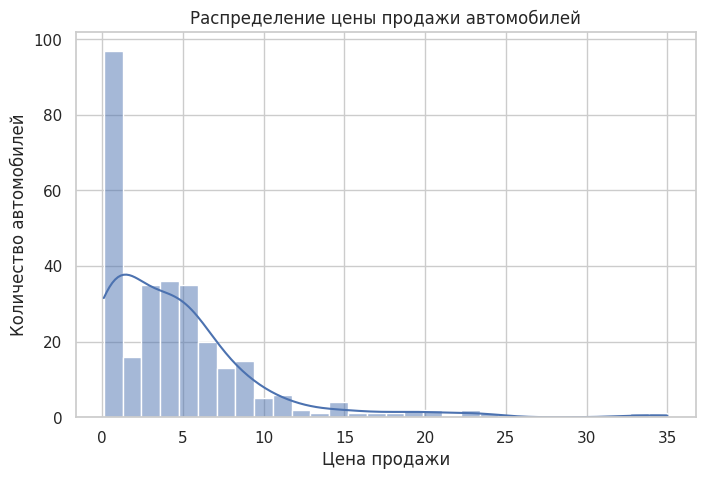

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Selling_Price',
    bins=30,
    kde=True
)

plt.title('Распределение цены продажи автомобилей')
plt.xlabel('Цена продажи')
plt.ylabel('Количество автомобилей')

plt.savefig('graph1.png',
            bbox_inches='tight')

plt.show()

Большинство проданных машин располагаются по цене до 10 млн. Может потребоваться отсечение более дорогих автомобилей для грамотной работы модели в силу их маленького количества.

## Распределение цена/возраст

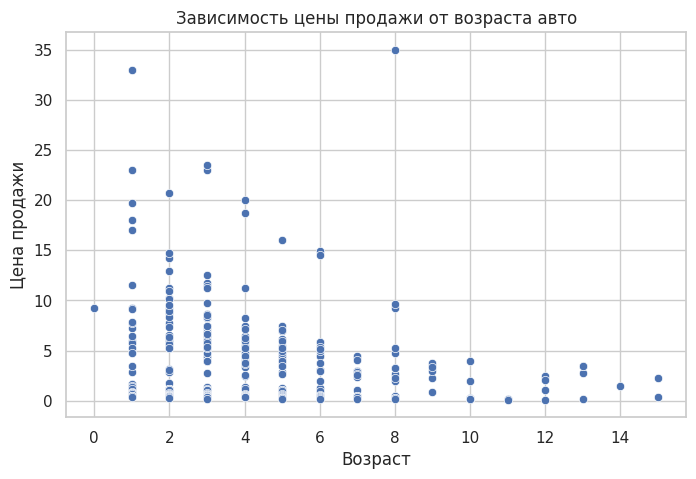

In [64]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Selling_Price'
)

plt.title('Зависимость цены продажи от возраста авто')
plt.xlabel('Возраст')
plt.ylabel('Цена продажи')

plt.savefig('graph2.png',
            bbox_inches='tight')

plt.show()

Общая тенденция: понижение цены автомобиля с увеличением возраста,
однако присутсвуют единичные выбросы

## Распределение цена/пробег

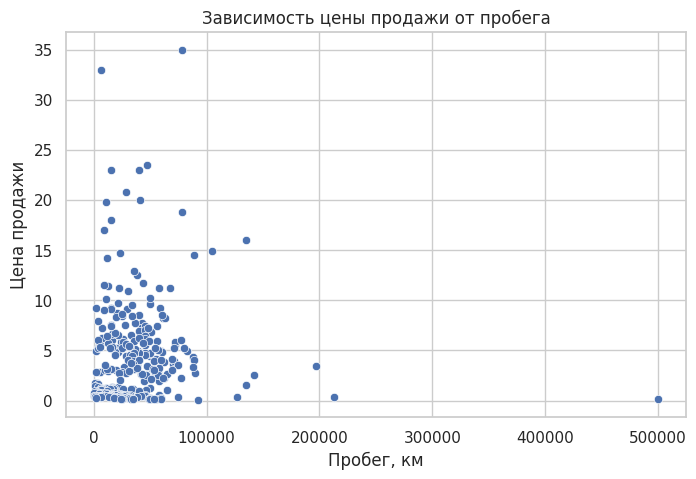

In [65]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Driven_kms',
    y='Selling_Price'
)

plt.title('Зависимость цены продажи от пробега')
plt.xlabel('Пробег, км')
plt.ylabel('Цена продажи')

plt.savefig('graph3.png',
            bbox_inches='tight')

plt.show()

Подавляющее большинство автомобилей имеют пробег до 100000 км и, соответственно, более высокую цену.

## Распределение цена/тип топлива

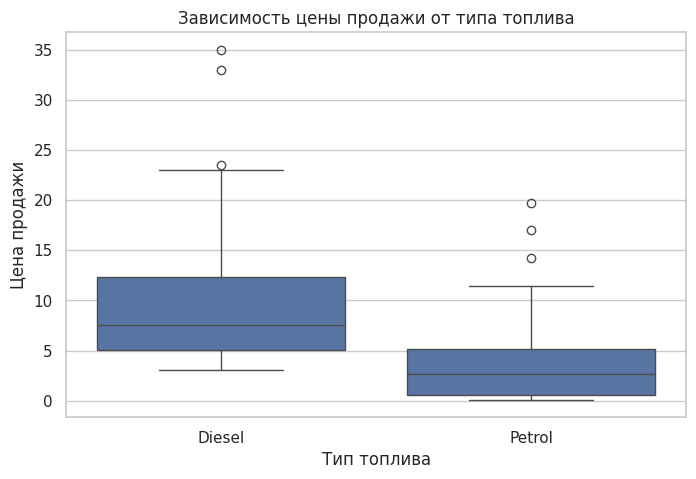

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Fuel_Type',
    y='Selling_Price'
)

plt.title('Зависимость цены продажи от типа топлива')
plt.xlabel('Тип топлива')
plt.ylabel('Цена продажи')

plt.savefig('graph4.png',
            bbox_inches='tight')

plt.show()

Медианная цена дизельных авто больше чем у бензиновых, при этом минимальная цена дизельной машины на уровне медианной бензиновой.

## Распределение цена/тип трансмисии

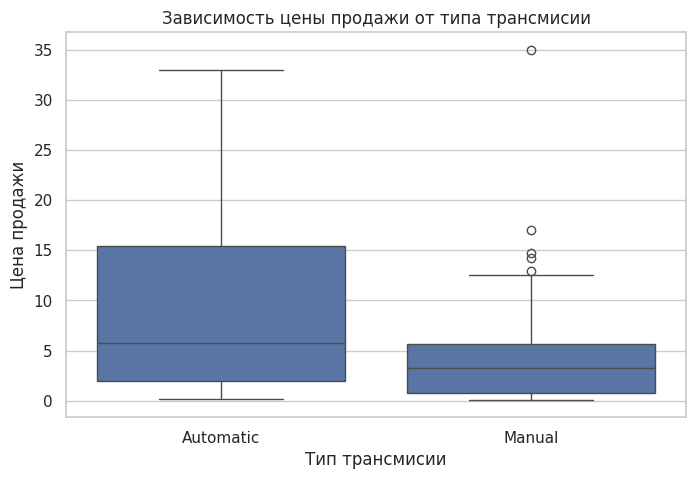

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Transmission',
    y='Selling_Price'
)

plt.title('Зависимость цены продажи от типа трансмисии')
plt.xlabel('Тип трансмисии')
plt.ylabel('Цена продажи')

plt.savefig('graph4.png',
            bbox_inches='tight')

plt.show()

Значительная часть машин с АКПП дороже чем с МКПП

## Распределение цена/продавец

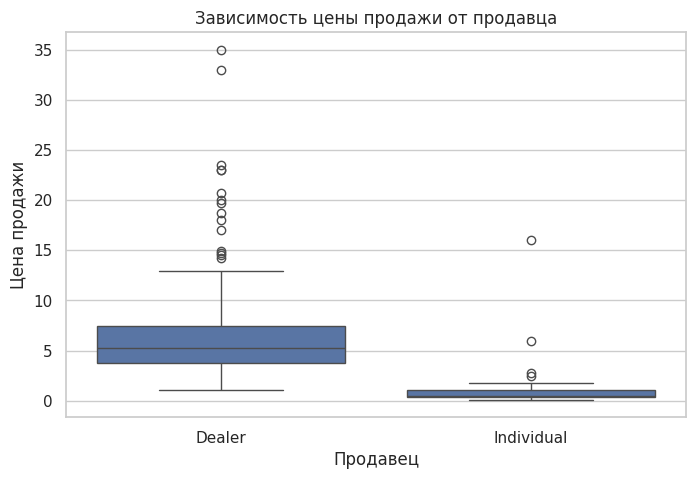

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Selling_type',
    y='Selling_Price'
)

plt.title('Зависимость цены продажи от продавца')
plt.xlabel('Продавец')
plt.ylabel('Цена продажи')

plt.savefig('graph4.png',
            bbox_inches='tight')

plt.show()

Дилеры продают сильно дороже владельцев

## Корреляция числовых признаков

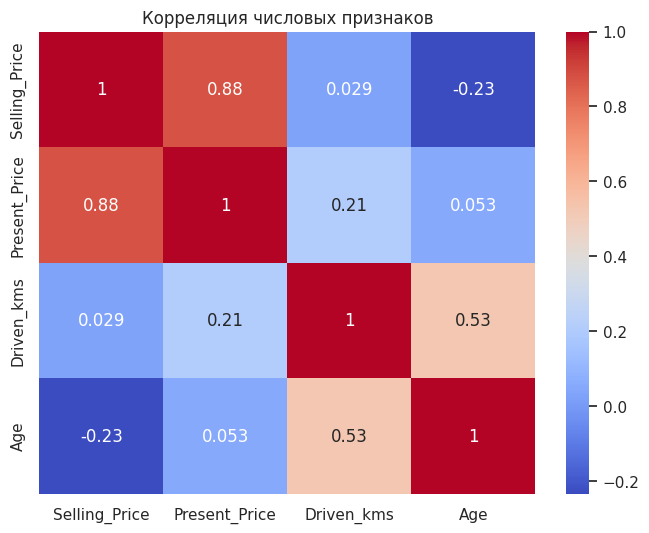

In [69]:
plt.figure(figsize=(8,6))

correlation = df[num_features].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Корреляция числовых признаков')

plt.savefig('graph5.png',
            bbox_inches='tight')

plt.show()

Самая большая корреляция (0.88) наблюдается у цены продажи и текущей цены нового автомобиля. Также достаточно сильную обратную связь (-0.53) показывают год выпуска и пробег (чем меньше год выпуска, тем больше пробег)